REGRESSION TRACK

In [1]:
import pandas as pd
DATA_PATH = "data/data.csv"
TARGET = "strength"
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Shape: 1030 rows x 14 columns


,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength,water_cement_ratio,total_binder,aggregate_to_cement,cement_water_interaction,age_strength_proxy
0,141.3,212.0,0.0,203.5,0.0,971.8,748.5,28,29.89,1.440188,353.3,12.174719,28754.55,5.291503
1,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,14,23.51,0.937235,335.4,11.113019,26736.87,3.741657
2,250.0,0.0,95.7,187.4,5.5,956.9,861.2,28,29.22,0.749597,345.7,7.272371,46850.00,5.291503
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85,0.857140,380.0,6.022534,60648.00,5.291503
4,154.8,183.4,0.0,193.3,9.1,1047.4,696.7,28,18.29,1.248700,338.2,11.266723,29922.84,5.291503


In [2]:
import pandas as pd
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cement                    1030 non-null   float64
 1   slag                      1030 non-null   float64
 2   ash                       1030 non-null   float64
 3   water                     1030 non-null   float64
 4   superplastic              1030 non-null   float64
 5   coarseagg                 1030 non-null   float64
 6   fineagg                   1030 non-null   float64
 7   age                       1030 non-null   int64  
 8   strength                  1030 non-null   float64
 9   water_cement_ratio        1030 non-null   float64
 10  total_binder              1030 non-null   float64
 11  aggregate_to_cement       1030 non-null   float64
 12  cement_water_interaction  1030 non-null   float64
 13  age_strength_proxy        1030 non-null   float64
dtypes: float

In [3]:
import pandas as pd

missing = pd.DataFrame({"n_missing": df.isna().sum(),"pct_missing": (df.isna().mean()*100).round(2),})
print("Missing values per column:")
print(missing.to_string())
n_dup = df.duplicated().sum()
pct_dup = (n_dup / len(df)) * 100
print(f"\nFully duplicated rows: {n_dup}  ({pct_dup:.2f}% of the data)")

Missing values per column:
                          n_missing  pct_missing
cement                            0          0.0
slag                              0          0.0
ash                               0          0.0
water                             0          0.0
superplastic                      0          0.0
coarseagg                         0          0.0
fineagg                           0          0.0
age                               0          0.0
strength                          0          0.0
water_cement_ratio                0          0.0
total_binder                      0          0.0
aggregate_to_cement               0          0.0
cement_water_interaction          0          0.0
age_strength_proxy                0          0.0

Fully duplicated rows: 25  (2.43% of the data)


In [4]:
import pandas as pd
desc = df.describe().T
desc["skew"] = df.skew()
desc["kurtosis"] = df.kurtosis()
desc.round(3)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
cement,1030.0,281.168,104.506,102.000,192.375,272.900,350.000,540.000,0.509,-0.521
slag,1030.0,73.896,86.279,0.000,0.000,22.000,142.950,359.400,0.801,-0.508
ash,1030.0,54.188,63.997,0.000,0.000,0.000,118.300,200.100,0.537,-1.329
water,1030.0,181.567,21.354,121.800,164.900,185.000,192.000,247.000,0.075,0.122
superplastic,1030.0,6.205,5.974,0.000,0.000,6.400,10.200,32.200,0.907,1.411
coarseagg,1030.0,972.919,77.754,801.000,932.000,968.000,1029.400,1145.000,-0.040,-0.599
fineagg,1030.0,773.580,80.176,594.000,730.950,779.500,824.000,992.600,-0.253,-0.102
age,1030.0,45.662,63.170,1.000,7.000,28.000,56.000,365.000,3.269,12.169
strength,1030.0,35.818,16.706,2.330,23.710,34.445,46.135,82.600,0.417,-0.314
water_cement_ratio,1030.0,0.748,0.314,0.267,0.533,0.675,0.935,1.882,0.958,0.734


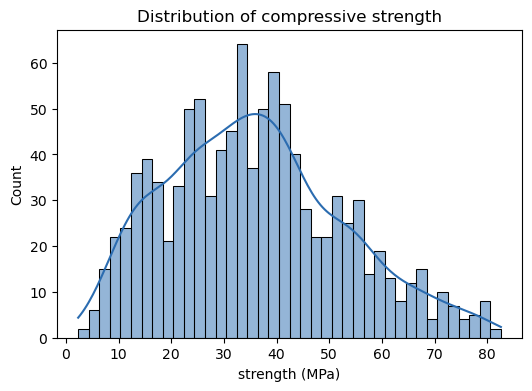

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.histplot(df[TARGET], bins=40, kde=True, color="#2b6cb0")
plt.title("Distribution of compressive strength")
plt.xlabel("strength (MPa)")
plt.ylabel("Count")
plt.show()

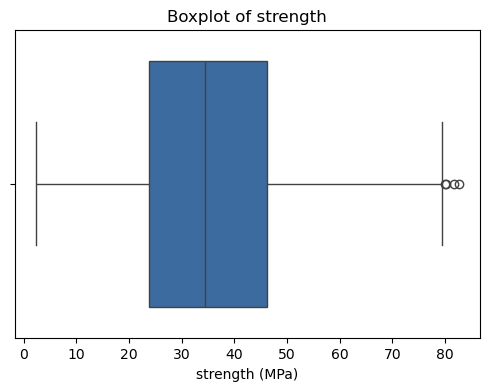

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.boxplot(x=df[TARGET], color="#2b6cb0")
plt.title("Boxplot of strength")
plt.xlabel("strength (MPa)")
plt.show()

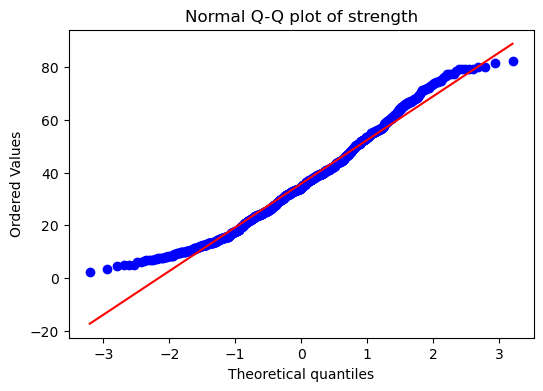

In [14]:
import matplotlib.pyplot as plt
from scipy import stats
plt.figure(figsize=(6, 4))
ax = plt.gca()
stats.probplot(df[TARGET], dist="norm", plot=ax)
plt.title("Normal Q-Q plot of strength")
plt.show()

In [11]:
print(f"mean   : {df[TARGET].mean():.2f} MPa")
print(f"median : {df[TARGET].median():.2f} MPa")
print(f"std    : {df[TARGET].std():.2f} MPa")
print(f"min    : {df[TARGET].min():.2f} MPa")
print(f"max    : {df[TARGET].max():.2f} MPa")
print(f"skew   : {df[TARGET].skew():.3f}")

mean   : 35.82 MPa
median : 34.45 MPa
std    : 16.71 MPa
min    : 2.33 MPa
max    : 82.60 MPa
skew   : 0.417
